# BNN Regression on Sinusoid using ```laplace-torch```

We fit a deterministic MAP regressor on a noisy sinusoid (`x ∈ [0, 8]`) and turn it into a
Bayesian model post-hoc with the Laplace approximation. We compare variants over the two key
axes from Laplace Redux, Hessian structure (diag / kron / full) and prior-precision tuning
(marglik / gridsearch), and inspect how the predictive uncertainty behaves, especially in the
extrapolation (OOD) region outside the training range.

In [11]:
from pathlib import Path
import sys
import os
import time
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from laplace import Laplace

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything, regression_uncertainty_stats, regression_metrics
from shared.helper.dataloaders import get_sinusoid_example

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 711
seed_everything(SEED)
sigma_noise = 0.3            # true data-generation noise (aleatoric)

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
checkpoint_dir = os.path.join("results", "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

Device: cuda


In [12]:
# Data + validation split + MAP
X_train, y_train, train_loader, X_test = get_sinusoid_example(n_data=150, sigma_noise=sigma_noise, batch_size=150)
X_train_np = X_train.flatten().numpy()
y_train_np = y_train.flatten().numpy()
x_grid = X_test.flatten().numpy()

# Held-out validation set (used by the gridsearch tuner; same split used for early stopping in the BNN notebook)
seed_everything(SEED + 1)
X_val = (torch.rand(50) * 8).unsqueeze(-1)
y_val = torch.sin(X_val) + sigma_noise * torch.randn_like(X_val)
val_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=50)

# Held-out test sets WITH targets, for scored metrics (NLL / RMSE / calibration)
seed_everything(SEED + 2)
X_test_id  = (torch.rand(100) * 8).unsqueeze(-1)                                 # in-distribution: x in [0, 8]
X_test_ood = torch.cat([torch.rand(60) * 5 - 5, torch.rand(60) * 5 + 8]).unsqueeze(-1)  # extrapolation: [-5,0] U [8,13]
y_test_id  = torch.sin(X_test_id)  + sigma_noise * torch.randn_like(X_test_id)
y_test_ood = torch.sin(X_test_ood) + sigma_noise * torch.randn_like(X_test_ood)
y_test_id_np  = y_test_id.flatten().numpy()
y_test_ood_np = y_test_ood.flatten().numpy()

# Visualization helper (identical in the Bayesian notebook)
TRAIN_LO, TRAIN_HI = 0.0, 8.0   # training x-range; outside this is OOD/extrapolation
def plot_prediction(x_grid, f_mu, epistemic_std, aleatoric_std, title, ax):
    epi = np.asarray(epistemic_std).ravel()
    ale = float(aleatoric_std)
    total = np.sqrt(epi ** 2 + ale ** 2)
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
    ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
    ax.scatter(X_train_np, y_train_np, c="tab:blue", s=12, alpha=0.5, zorder=3, label="Train")
    ax.plot(x_grid, f_mu, color="tab:orange", lw=2, label="Predictive mean")
    ax.fill_between(x_grid, f_mu - 2*total, f_mu + 2*total, color="tab:orange", alpha=0.20, label="±2σ total")
    ax.fill_between(x_grid, f_mu - 2*epi, f_mu + 2*epi, color="tab:purple", alpha=0.30, label="±2σ epistemic")
    ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)

def get_model():
    seed_everything(SEED)
    return torch.nn.Sequential(torch.nn.Linear(1, 50), torch.nn.Tanh(), torch.nn.Linear(50, 1))

# Train / load the shared MAP regressor
map_ckpt = str(ROOT / "results" / "checkpoints" / f"sinusoid_map_seed{SEED}.pt")
map_model = get_model()
criterion = torch.nn.MSELoss()
if checkpoint_exists(map_ckpt):
    map_model.load_state_dict(load_checkpoint(map_ckpt, map_location="cpu")["model_state_dict"])
    print("Loaded MAP checkpoint")
else:
    opt = torch.optim.Adam(map_model.parameters(), lr=1e-2)
    fit_start = time.time()
    for epoch in range(1000):
        for xb, yb in train_loader:
            opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
    save_checkpoint({"model_state_dict": map_model.state_dict(), "fit_time": time.time() - fit_start}, map_ckpt)
    print(f"Trained MAP ({time.time() - fit_start:.1f}s)")
map_model.eval()
print(f"MAP parameters: {sum(p.numel() for p in map_model.parameters()):,} ")

# MAP residual std on train (noise estimate used to set sigma_noise for gridsearch)
with torch.no_grad():
    map_resid_std = float((y_train - map_model(X_train)).std().item())

def la_predict(la_model, X):
    """Return (mean, epistemic_std) numpy arrays on grid X."""
    f_mu, f_var = la_model(X)
    return f_mu.squeeze().detach().cpu().numpy(), f_var.squeeze().sqrt().detach().cpu().numpy()

variant_results = {}

Loaded MAP checkpoint
MAP parameters: 151 


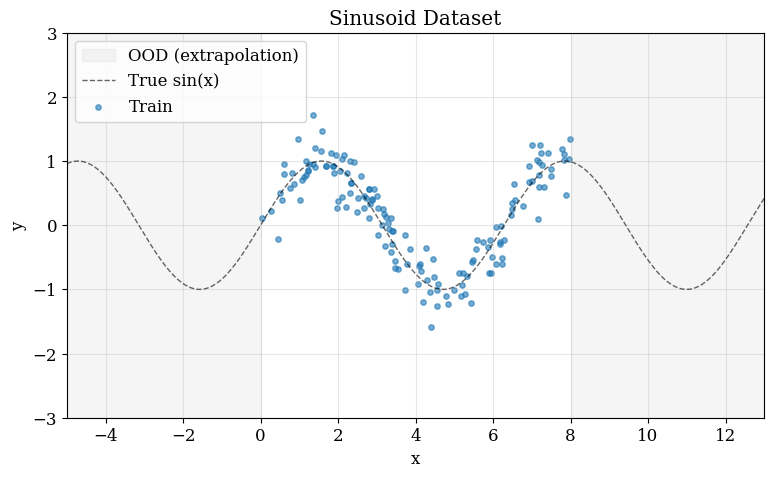

In [13]:
# Dataset visualization
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.08)
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.08, label="OOD (extrapolation)")
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.6, label="Train")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Sinusoid Dataset")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_dataset.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
def fit_variant(spec):
    """Fit a Laplace regression variant on the shared MAP and tune its hyperparameters."""
    base = get_model()
    base.load_state_dict(map_model.state_dict())
    la = Laplace(base, "regression", subset_of_weights=spec["subset"], hessian_structure=spec["hessian"])

    fit_start = time.time()
    la.fit(train_loader)
    if spec["tune"] == "marglik":
        la.optimize_prior_precision(method="marglik")
    else:  # gridsearch on held-out NLL; sigma_noise fixed to the MAP residual std
        la.sigma_noise = torch.tensor(map_resid_std)
        la.optimize_prior_precision(method="gridsearch", val_loader=val_loader)
    fit_time = time.time() - fit_start

    metrics = {
        "Hessian_Structure": spec["hessian"],
        "Subset_Of_Weights": spec["subset"],
        "Tune_Method": spec["tune"],
        "Fit_Time (s)": fit_time,
        "Prior_Precision": float(np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0]),
        "Sigma_Noise": float(la.sigma_noise.item()),
    }
    return la, metrics


# Variant grid: (diag/kron/full, all weights) + (full/kron, last layer) x tuning = 10 variants
variant_specs = []
for subset, hessians in [("all", ["diag", "kron", "full"]), ("last_layer", ["full", "kron"])]:
    scope = "all" if subset == "all" else "last layer"
    for hessian in hessians:
        for tune in ["marglik", "gridsearch"]:
            variant_specs.append({
                "variant_name": f"{hessian}_{subset}_{tune}",
                "hessian": hessian,
                "subset": subset,
                "tune": tune,
                "plot_title": f"{hessian.capitalize()} / {scope} / {tune}",
            })
variant_results = {}
print(f"Configured {len(variant_specs)} Laplace regression variants.")

Configured 10 Laplace regression variants.


In [15]:
# Run all variants -> build variant_eval_df
variant_eval_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    print(f"  Fitting: {vname}")
    la, v_metrics = fit_variant(spec)
    sigma = v_metrics["Sigma_Noise"]
    f_mu, epi_std = la_predict(la, X_test)                     # grid (for figures)
    mu_id, epi_id = la_predict(la, X_test_id)                  # held-out ID test (for scored metrics)
    total_id = np.sqrt(epi_id ** 2 + sigma ** 2)
    v_metrics.update(regression_uncertainty_stats(epi_id, sigma))
    v_metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))
    variant_results[vname] = {"la": la, "f_mu": f_mu, "epi_std": epi_std, "sigma": sigma, "metrics": v_metrics}
    variant_eval_rows.append(v_metrics)

variant_eval_df = pd.DataFrame(variant_eval_rows, index=[s["plot_title"] for s in variant_specs])
variant_eval_df.index.name = "Variant"
print(f"\nEvaluated {len(variant_eval_rows)} variants.")

  Fitting: diag_all_marglik
  Fitting: diag_all_gridsearch
  Fitting: kron_all_marglik
  Fitting: kron_all_gridsearch
  Fitting: full_all_marglik
  Fitting: full_all_gridsearch
  Fitting: full_last_layer_marglik
  Fitting: full_last_layer_gridsearch
  Fitting: kron_last_layer_marglik
  Fitting: kron_last_layer_gridsearch

Evaluated 10 variants.


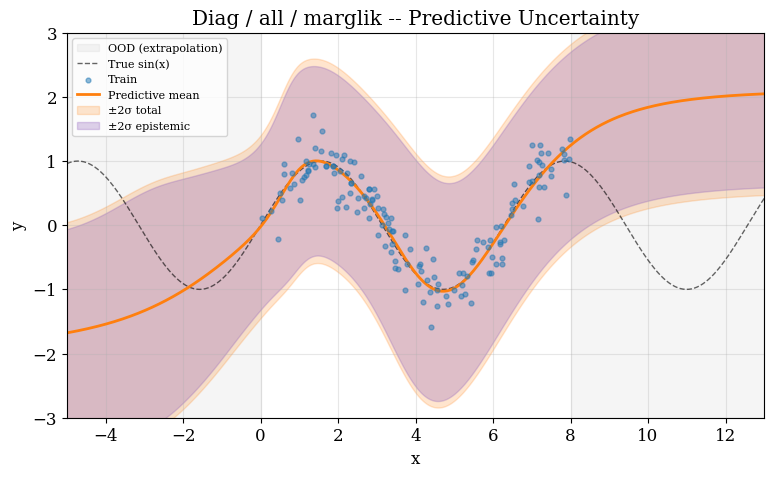

  Saved figure for: diag_all_marglik


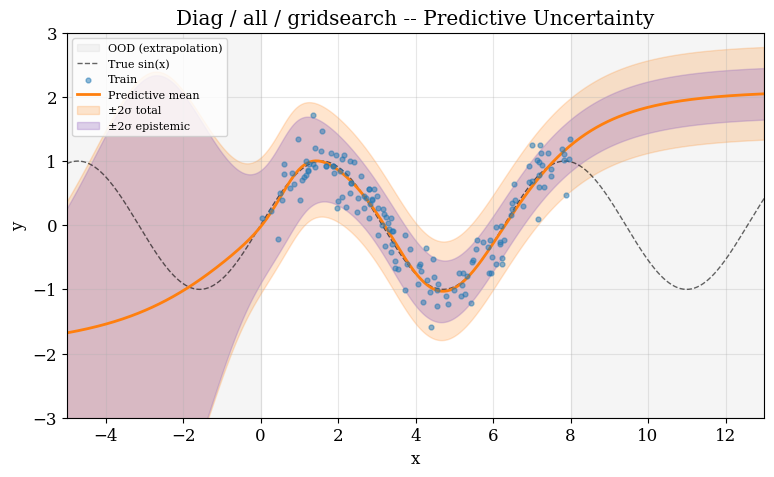

  Saved figure for: diag_all_gridsearch


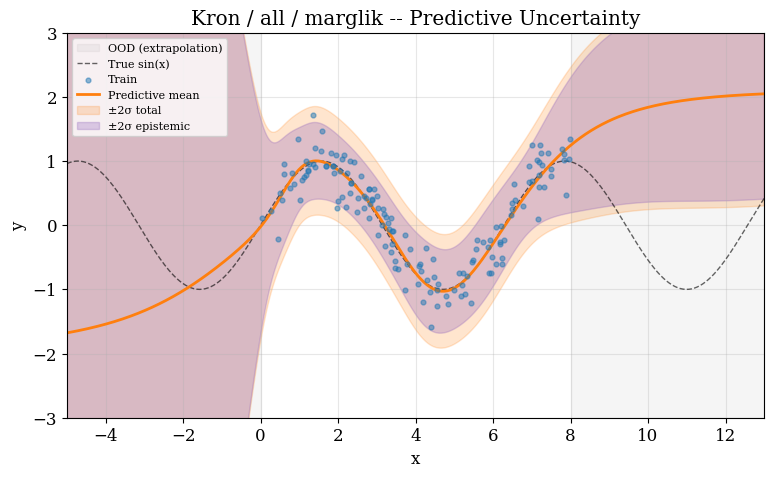

  Saved figure for: kron_all_marglik


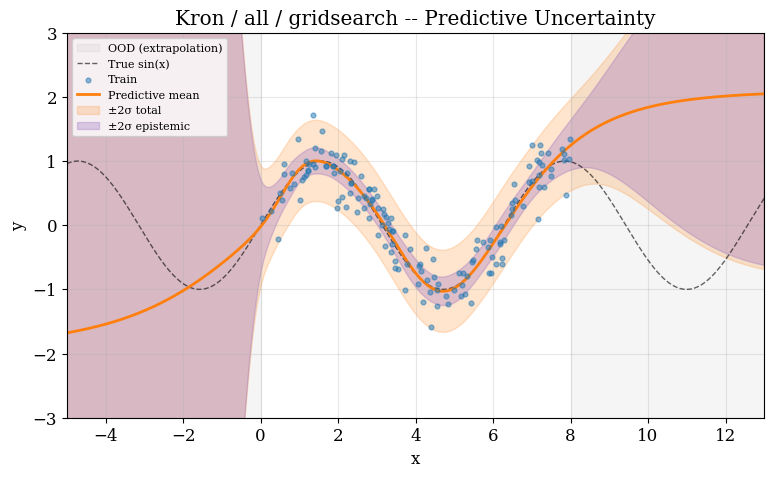

  Saved figure for: kron_all_gridsearch


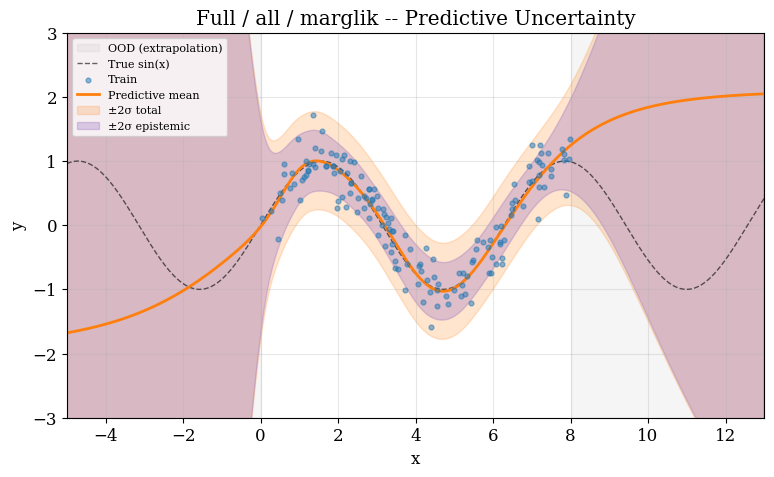

  Saved figure for: full_all_marglik


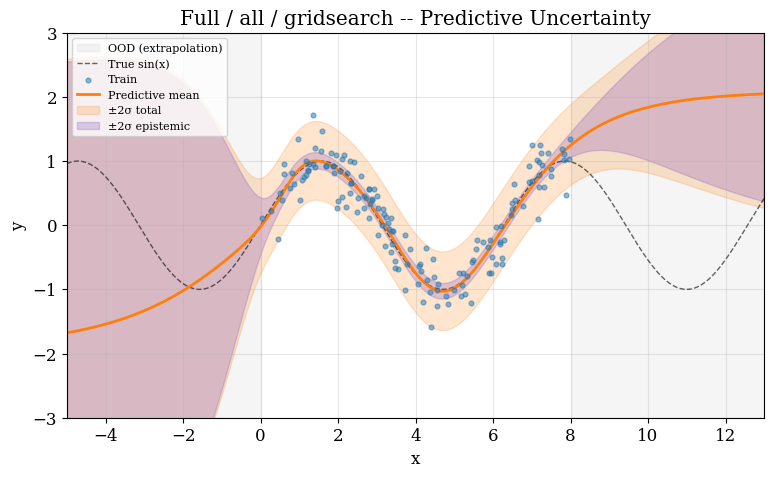

  Saved figure for: full_all_gridsearch


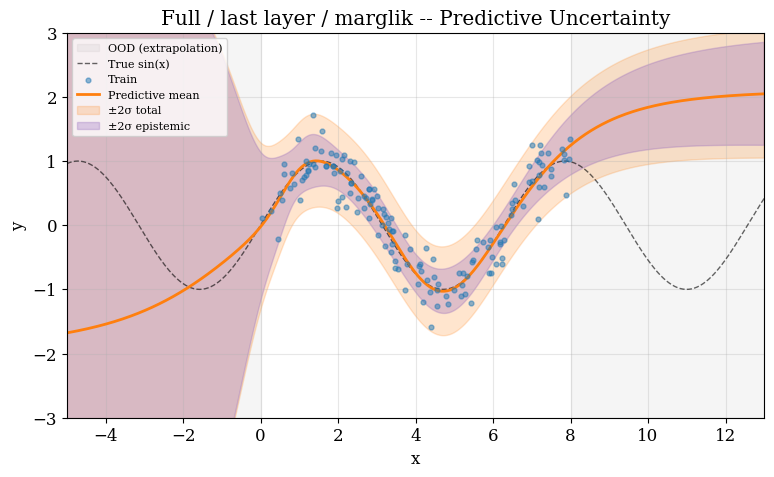

  Saved figure for: full_last_layer_marglik


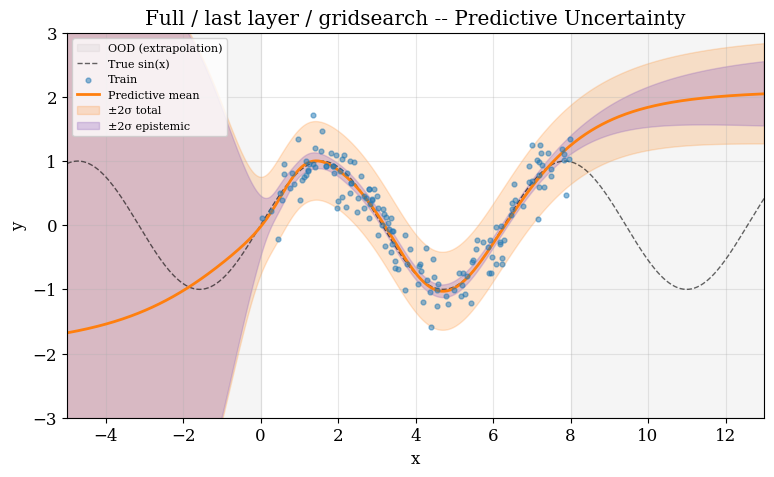

  Saved figure for: full_last_layer_gridsearch


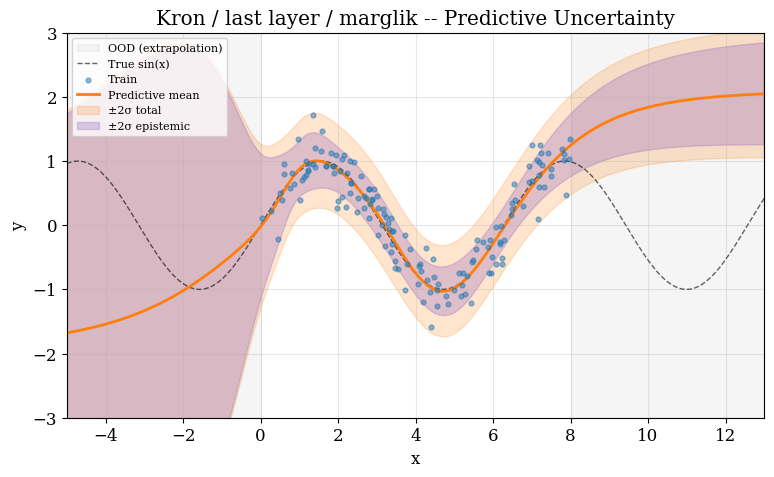

  Saved figure for: kron_last_layer_marglik


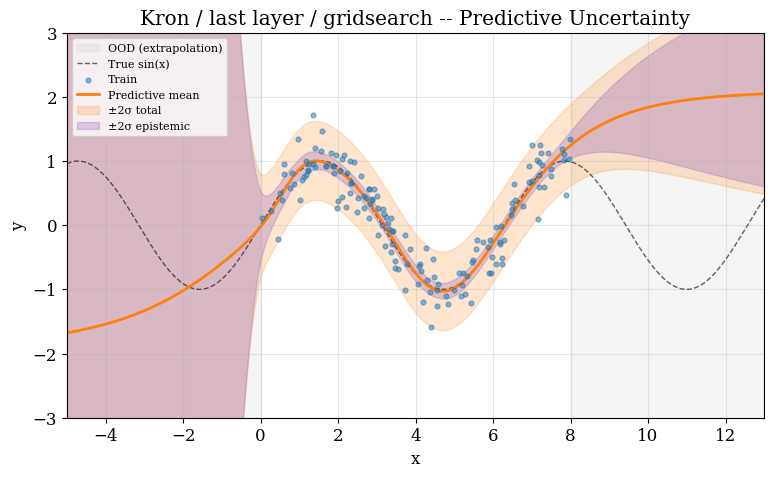

  Saved figure for: kron_last_layer_gridsearch

Done: 10 figures written to ../figures


In [16]:
# Per-variant regression figures (mean + epistemic/total bands; OOD region shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    res = variant_results[vname]
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    plot_prediction(x_grid, res["f_mu"], res["epi_std"], sigma_noise, f"{title} -- Predictive Uncertainty", ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_prediction.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved figure for: {vname}")
print(f"\nDone: {len(variant_specs)} figures written to {FIGURES_DIR}")

In [17]:
# Final metrics table (uncertainty stats)
variant_table = variant_eval_df.copy()
variant_table.index.name = "Model Type"
preferred_cols = [
    "Hessian_Structure", "Subset_Of_Weights", "Tune_Method", "Fit_Time (s)", "Prior_Precision", "Sigma_Noise",
    "RMSE", "MAE", "NLL", "Calibration_MAE", "Calibration_MSE", "Calibration_Corr", "Max_Calibration_Gap",
    "Coverage_68", "Coverage_95",
    "Mean_Epistemic_Std", "Mean_Aleatoric_Std", "Mean_Total_Std",
]
existing = [c for c in preferred_cols if c in variant_table.columns]
variant_table = variant_table[existing + [c for c in variant_table.columns if c not in existing]]

disp = variant_table.copy()
for c in disp.columns:
    if pd.api.types.is_float_dtype(disp[c]):
        disp[c] = disp[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "-")
print("Sinusoid Laplace -- Variant-Level Uncertainty Benchmarks")
display(disp)

os.makedirs("results/metrics", exist_ok=True)
variant_table.to_csv("results/metrics/sinusoid_laplace_variant_metrics.csv")
print("\nSaved metrics to results/metrics/sinusoid_laplace_variant_metrics.csv")

Sinusoid Laplace -- Variant-Level Uncertainty Benchmarks


,Hessian_Structure,Subset_Of_Weights,Tune_Method,Fit_Time (s),Prior_Precision,Sigma_Noise,RMSE,MAE,NLL,Calibration_MAE,Calibration_MSE,Calibration_Corr,Max_Calibration_Gap,Coverage_68,Coverage_95,Mean_Epistemic_Std,Mean_Aleatoric_Std,Mean_Total_Std
Model Type,,,,,,,,,,,,,,,,,,
Diag / all / marglik,diag,all,marglik,0.0344,0.9094,1.0000,0.2807,0.2218,1.1789,0.1700,0.0416,0.9260,0.3200,1.0000,1.0000,0.7749,1.0000,1.2658
Diag / all / gridsearch,diag,all,gridsearch,0.1002,0.0152,0.2731,0.2807,0.2218,0.2427,0.0600,0.0050,0.9886,0.1100,0.8700,0.9700,0.2681,0.2731,0.3852
Kron / all / marglik,kron,all,marglik,0.0351,0.1820,1.0000,0.2807,0.2218,1.0081,0.1555,0.0338,0.9397,0.2900,1.0000,1.0000,0.3311,1.0000,1.0556
Kron / all / gridsearch,kron,all,gridsearch,0.1089,0.0152,0.2731,0.2807,0.2218,0.1506,0.0427,0.0027,0.9946,0.0900,0.7500,0.9500,0.1100,0.2731,0.2955
Full / all / marglik,full,all,marglik,0.8994,0.0804,1.0000,0.2807,0.2218,0.9844,0.1527,0.0323,0.9423,0.2800,1.0000,1.0000,0.2323,1.0000,1.0288
Full / all / gridsearch,full,all,gridsearch,0.6100,1.3219,0.2731,0.2807,0.2218,0.1492,0.0427,0.0028,0.9945,0.0900,0.7100,0.9400,0.0628,0.2731,0.2808
Full / last layer / marglik,full,last_layer,marglik,0.3943,0.6726,1.0000,0.2807,0.2218,0.9753,0.1518,0.0319,0.9431,0.2800,1.0000,1.0000,0.1832,1.0000,1.0186
Full / last layer / gridsearch,full,last_layer,gridsearch,0.0707,0.5214,0.2731,0.2807,0.2218,0.1502,0.0427,0.0028,0.9945,0.0900,0.7100,0.9400,0.0556,0.2731,0.2794
Kron / last layer / marglik,kron,last_layer,marglik,0.0487,0.7958,1.0000,0.2807,0.2218,0.9780,0.1518,0.0319,0.9431,0.2800,1.0000,1.0000,0.2004,1.0000,1.0216



Saved metrics to results/metrics/sinusoid_laplace_variant_metrics.csv


## In-Distribution vs OOD (extrapolation) Test

The training data lives on `x ∈ [0, 8]`; everything outside is out-of-distribution. A well-behaved
Bayesian regressor should show higher epistemic uncertainty in the extrapolation region than
inside the data, its "I haven't seen data here" signal. We compare mean epistemic std on the grid
points inside vs outside the training range for every variant.

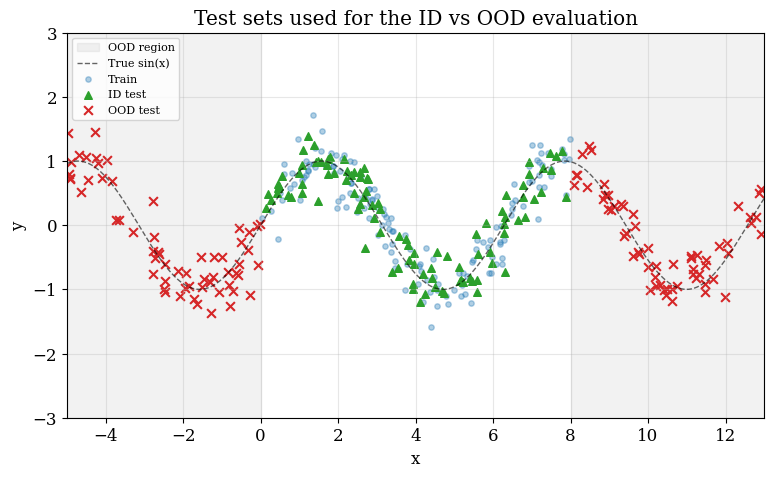

In [18]:
# What is given to test OOD: train data + held-out ID test + OOD test points
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD region")
ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
ax.plot(x_grid, np.sin(x_grid), "k--", lw=1, alpha=0.6, label="True sin(x)")
ax.scatter(X_train_np, y_train_np, c="tab:blue", s=15, alpha=0.35, label="Train")
ax.scatter(X_test_id.flatten().numpy(), y_test_id_np, c="tab:green", marker="^", s=30, label="ID test")
ax.scatter(X_test_ood.flatten().numpy(), y_test_ood_np, c="tab:red", marker="x", s=40, label="OOD test")
ax.set_xlim(-5, 13); ax.set_ylim(-3, 3)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Test sets used for the ID vs OOD evaluation")
ax.legend(loc="upper left", fontsize=8); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(FIGURES_DIR, "sinusoid_ood_testsets.png"), dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ID vs OOD scored metrics per variant (held-out test sets with targets)
ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    la = variant_results[vname]["la"]; sigma = variant_results[vname]["sigma"]
    mu_id,  epi_id  = la_predict(la, X_test_id)
    mu_ood, epi_ood = la_predict(la, X_test_ood)
    m_id  = regression_metrics(y_test_id_np,  mu_id,  np.sqrt(epi_id  ** 2 + sigma ** 2))
    m_ood = regression_metrics(y_test_ood_np, mu_ood, np.sqrt(epi_ood ** 2 + sigma ** 2))
    ood_rows.append({
        "ID NLL": m_id["NLL"],                "OOD NLL": m_ood["NLL"],
        "ID RMSE": m_id["RMSE"],              "OOD RMSE": m_ood["RMSE"],
        "ID Coverage_95": m_id["Coverage_95"], "OOD Coverage_95": m_ood["Coverage_95"],
        "ID Epistemic": float(epi_id.mean()),  "OOD Epistemic": float(epi_ood.mean()),
        "Epistemic Ratio (OOD/ID)": float(epi_ood.mean() / epi_id.mean()) if epi_id.mean() > 0 else float("inf"),
    })
ood_df = pd.DataFrame(ood_rows, index=[s["plot_title"] for s in variant_specs])
ood_df.index.name = "Variant"
print("ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1")
display(ood_df.round(4))

os.makedirs("results/metrics", exist_ok=True)
ood_df.to_csv("results/metrics/sinusoid_laplace_ood_metrics.csv")
print("\nSaved OOD metrics to results/metrics/sinusoid_laplace_ood_metrics.csv")

ID vs OOD: NLL/RMSE should be HIGHER and Coverage_95 should DROP on OOD; epistemic ratio > 1


,ID NLL,OOD NLL,ID RMSE,OOD RMSE,ID Coverage_95,OOD Coverage_95,ID Epistemic,OOD Epistemic,Epistemic Ratio (OOD/ID)
Variant,,,,,,,,,
Diag / all / marglik,1.1789,2.2182,0.2807,1.8337,1.00,0.7250,0.7749,0.7690,0.9923
Diag / all / gridsearch,0.2427,11.1976,0.2807,1.8337,0.97,0.4750,0.2681,0.6965,2.5983
Kron / all / marglik,1.0081,2.4158,0.2807,1.8337,1.00,0.8083,0.3311,2.0667,6.2412
Kron / all / gridsearch,0.1506,3.2418,0.2807,1.8337,0.95,0.6333,0.1100,4.3188,39.2481
Full / all / marglik,0.9844,2.3652,0.2807,1.8337,1.00,1.0000,0.2323,3.8628,16.6317
Full / all / gridsearch,0.1492,4.5579,0.2807,1.8337,0.94,0.5583,0.0628,0.9689,15.4246
Full / last layer / marglik,0.9753,2.4810,0.2807,1.8337,1.00,0.7167,0.1832,1.2100,6.6060
Full / last layer / gridsearch,0.1502,11.6709,0.2807,1.8337,0.94,0.5417,0.0556,1.0362,18.6254
Kron / last layer / marglik,0.9780,2.4427,0.2807,1.8337,1.00,0.7167,0.2004,0.9708,4.8439



Saved OOD metrics to results/metrics/sinusoid_laplace_ood_metrics.csv


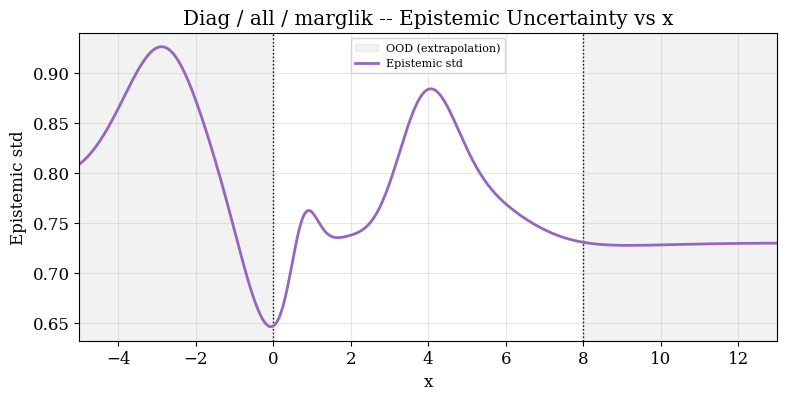

  Saved OOD epistemic figure for: diag_all_marglik


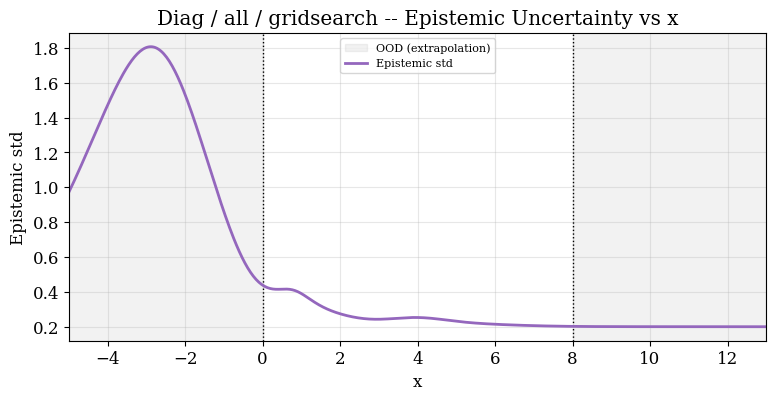

  Saved OOD epistemic figure for: diag_all_gridsearch


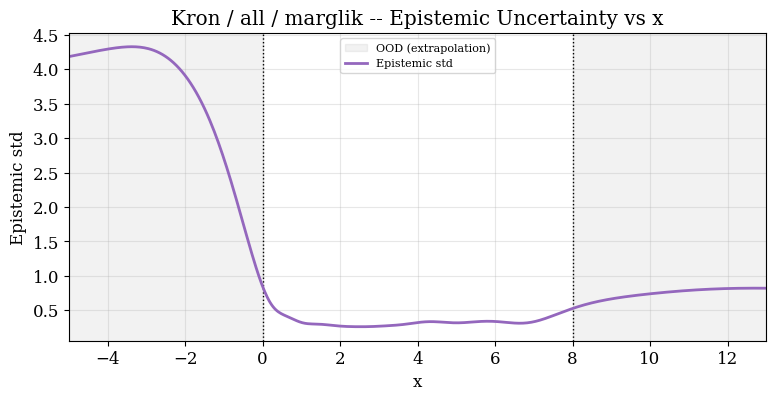

  Saved OOD epistemic figure for: kron_all_marglik


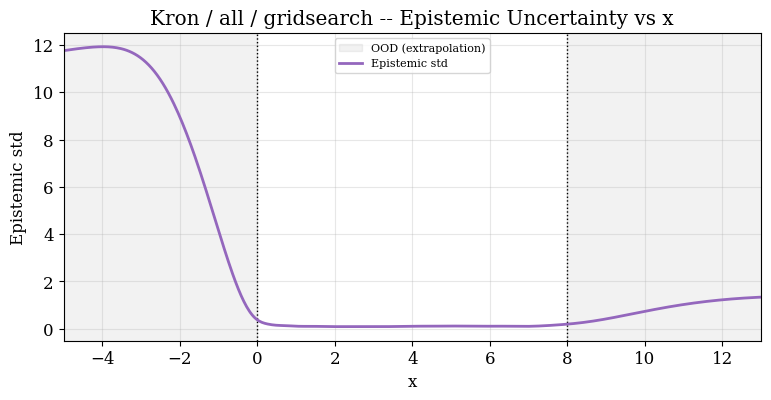

  Saved OOD epistemic figure for: kron_all_gridsearch


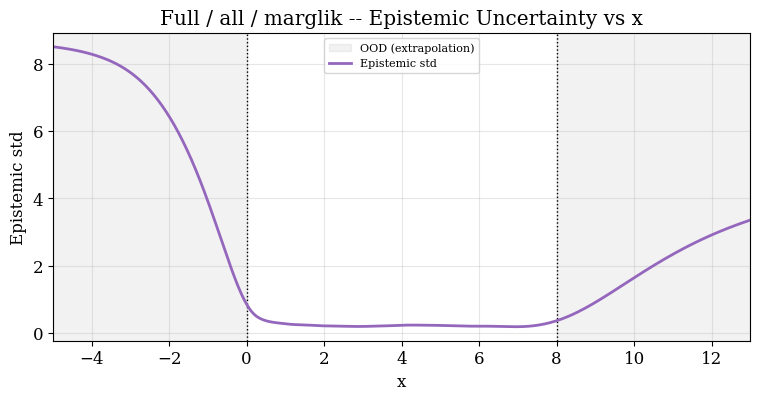

  Saved OOD epistemic figure for: full_all_marglik


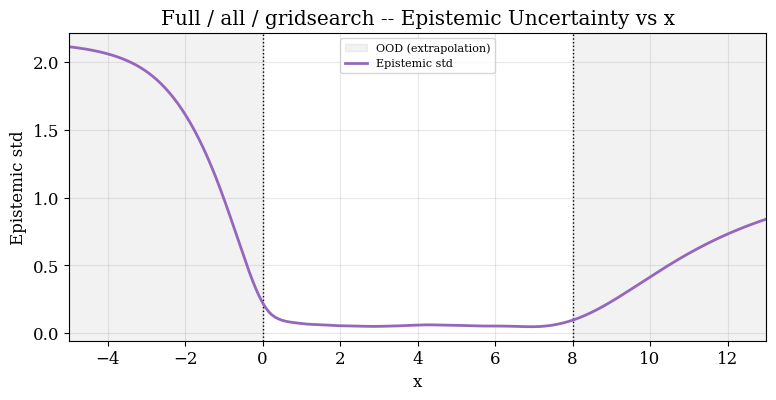

  Saved OOD epistemic figure for: full_all_gridsearch


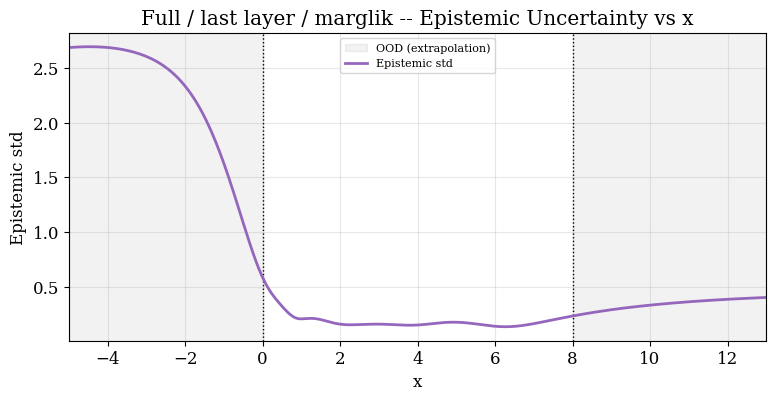

  Saved OOD epistemic figure for: full_last_layer_marglik


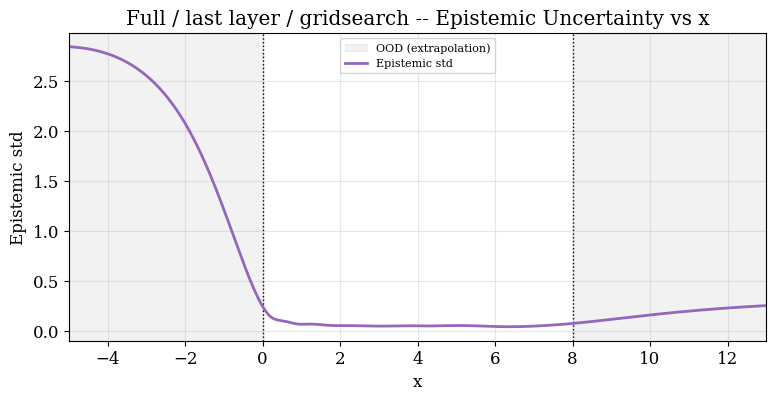

  Saved OOD epistemic figure for: full_last_layer_gridsearch


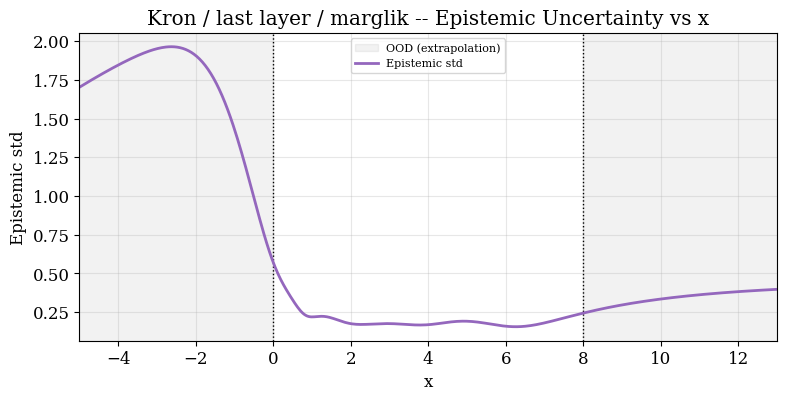

  Saved OOD epistemic figure for: kron_last_layer_marglik


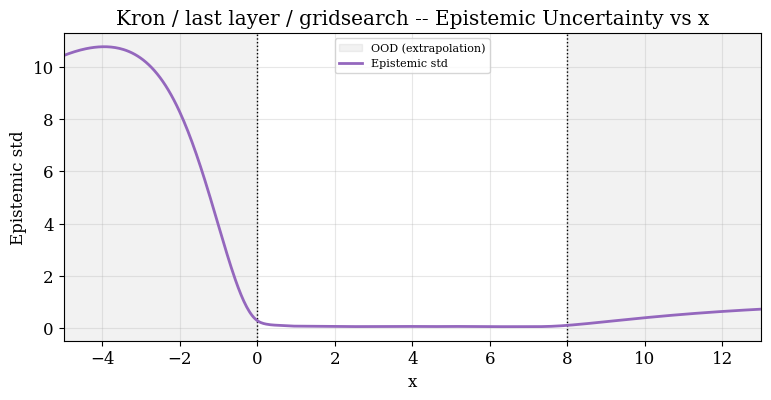

  Saved OOD epistemic figure for: kron_last_layer_gridsearch

Done: 10 OOD epistemic figures written to ../figures


In [20]:
# Per-variant OOD visualization: epistemic std across x (ID region clear, OOD shaded)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    epi = variant_results[vname]["epi_std"]
    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.axvspan(-5, TRAIN_LO, color="gray", alpha=0.10, label="OOD (extrapolation)")
    ax.axvspan(TRAIN_HI, 13, color="gray", alpha=0.10)
    ax.axvline(TRAIN_LO, color="k", ls=":", lw=1)
    ax.axvline(TRAIN_HI, color="k", ls=":", lw=1)
    ax.plot(x_grid, epi, color="tab:purple", lw=2, label="Epistemic std")
    ax.set_xlim(-5, 13)
    ax.set_xlabel("x"); ax.set_ylabel("Epistemic std")
    ax.set_title(f"{title} -- Epistemic Uncertainty vs x")
    ax.legend(loc="upper center", fontsize=8); ax.grid(True, alpha=0.3)
    fig.savefig(os.path.join(FIGURES_DIR, f"sinusoid_{vname}_ood_epistemic.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved OOD epistemic figure for: {vname}")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures written to {FIGURES_DIR}")